# Multiclass classification with imbalanced classes

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multiclass import OneVsOneClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tqdm import tqdm

In [2]:
pd.options.mode.chained_assignment = None 

In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")

In [4]:
RANDOM_STATE = 42
TRAIN_SIZE = 0.75
rng = np.random.default_rng(RANDOM_STATE)

## 1. Data Loading

In [5]:
from sklearn.datasets import load_wine

data = load_wine(as_frame=True)

X = data.data
y = data.target

Let's check the dataset's features, data types, and missing values

In [6]:
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


Now let's rename some columns for convenience

In [7]:
X.rename(columns={'alcalinity_of_ash': 'alk_ash', 'nonflavanoid_phenols': 'nonfl_phen', 'color_intensity': 'color_int',
                  'proanthocyanins': 'pr_an_cyan', 'od280/od315_of_diluted_wines': 'od280_od315'}, inplace=True)

In [8]:
X.head()

,alcohol,malic_acid,ash,alk_ash,magnesium,total_phenols,flavanoids,nonfl_phen,pr_an_cyan,color_int,hue,od280_od315,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [9]:
# data types
X.dtypes

alcohol          float64
malic_acid       float64
ash              float64
alk_ash          float64
magnesium        float64
total_phenols    float64
flavanoids       float64
nonfl_phen       float64
pr_an_cyan       float64
color_int        float64
hue              float64
od280_od315      float64
proline          float64
dtype: object

All featires are float and we don't need to code them

In [10]:
# check for missing values
X.isna().sum()

alcohol          0
malic_acid       0
ash              0
alk_ash          0
magnesium        0
total_phenols    0
flavanoids       0
nonfl_phen       0
pr_an_cyan       0
color_int        0
hue              0
od280_od315      0
proline          0
dtype: int64

So there is no missing values

Now we'll observe the count of target value classes

In [11]:
y.value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

Thus, we are dealing with a **multiclass classification problem**.

It should also be noted that the classes in the target variable are **not balanced**. Therefore, accuracy will not perform well as a model quality metric. Since we have no specific requirements regarding whether to prioritize precision or recall, we will use the `f1-score` as our metric.

## 2. EDA and data handling

We split the data into training and test sets. Since the classes are imbalanced, we set the `stratify` parameter to preserve the class distribution when splitting.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state = RANDOM_STATE, stratify=y)

Further unvestigation will be performed for the train set 

Let's check pairwise correlation of features 

In [13]:
corr = X_train.corr()
corr.style.background_gradient(cmap='coolwarm')

,alcohol,malic_acid,ash,alk_ash,magnesium,total_phenols,flavanoids,nonfl_phen,pr_an_cyan,color_int,hue,od280_od315,proline
alcohol,1.000000,0.048448,0.288015,-0.286914,0.268460,0.311278,0.287921,-0.147389,0.095828,0.526565,-0.067012,0.097818,0.646587
malic_acid,0.048448,1.000000,0.154892,0.275699,-0.045455,-0.317934,-0.375415,0.217966,-0.215259,0.210404,-0.561199,-0.360611,-0.201228
ash,0.288015,0.154892,1.000000,0.442529,0.235842,0.133245,0.080593,0.188777,-0.012200,0.271603,-0.075389,-0.053457,0.229329
alk_ash,-0.286914,0.275699,0.442529,1.000000,-0.090453,-0.291692,-0.372614,0.329221,-0.173944,-0.016130,-0.251954,-0.285893,-0.462029
magnesium,0.268460,-0.045455,0.235842,-0.090453,1.000000,0.200909,0.161697,-0.277451,0.256439,0.189974,0.052314,0.032602,0.401703
total_phenols,0.311278,-0.317934,0.133245,-0.291692,0.200909,1.000000,0.858793,-0.407187,0.592119,-0.053982,0.434608,0.695982,0.496940
flavanoids,0.287921,-0.375415,0.080593,-0.372614,0.161697,0.858793,1.000000,-0.511695,0.653958,-0.185480,0.557284,0.784959,0.502657
nonfl_phen,-0.147389,0.217966,0.188777,0.329221,-0.277451,-0.407187,-0.511695,1.000000,-0.325089,0.119873,-0.231407,-0.490324,-0.298110
pr_an_cyan,0.095828,-0.215259,-0.012200,-0.173944,0.256439,0.592119,0.653958,-0.325089,1.000000,-0.068963,0.333344,0.508270,0.294190
color_int,0.526565,0.210404,0.271603,-0.016130,0.189974,-0.053982,-0.185480,0.119873,-0.068963,1.000000,-0.553938,-0.433048,0.302882


There is a fairly strong correlation between the features `'total_phenols'` and `'flavanoids'`. In practice, if the correlation coefficient exceeds 0.9, it is recommended to remove one of the features (although in some tasks, such as credit scoring, the threshold is considerably lower). In this case, the correlation coefficient is 0.86, so for now we will keep both features.

We'll check fearures' distributions to find out if there are outliers 

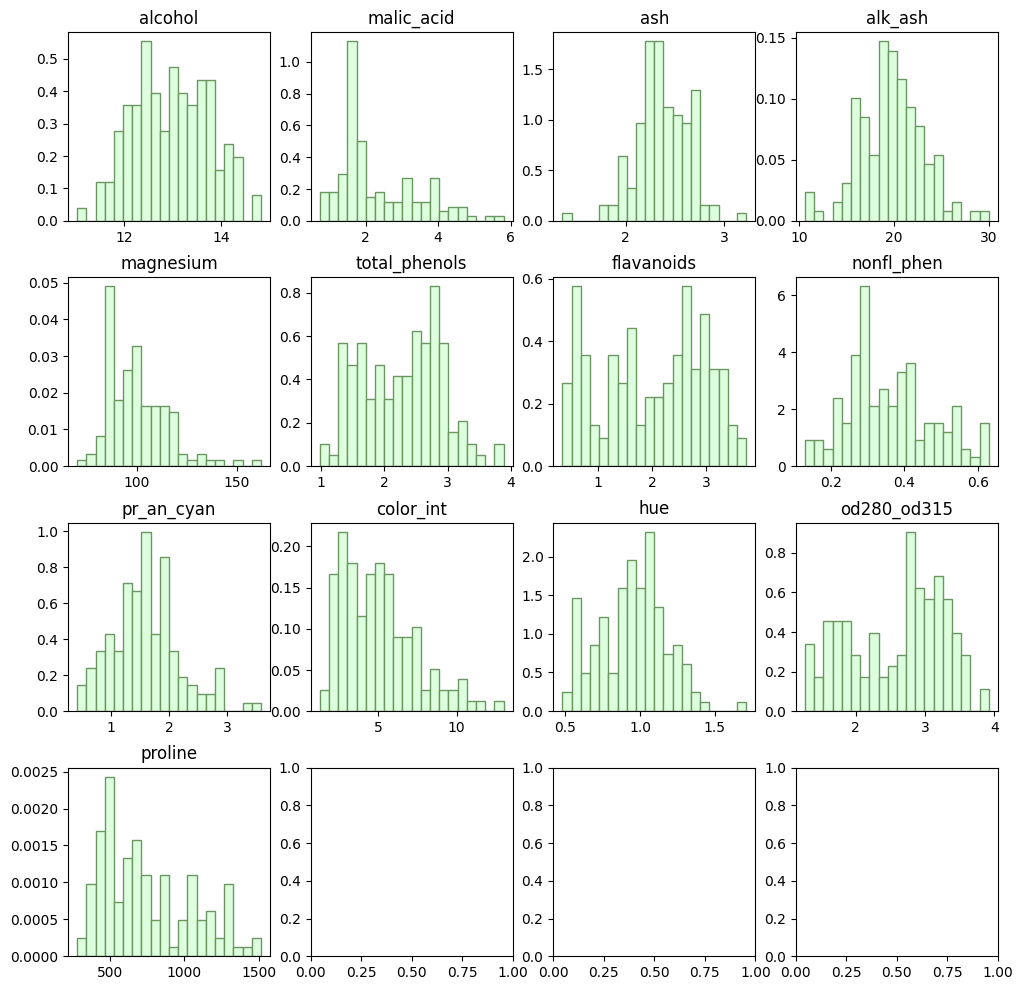

In [14]:
from matplotlib import pyplot as plt

fig, a = plt.subplots(4, 4, figsize=(12, 12))
plt.subplots_adjust(wspace=0.2, hspace=0.3)

for i in range(4):
    for j in range(4):
        if i*4+j < 13:
            a[i, j].set_title(X_train.columns[i*4+j])
            a[i, j].hist(X_train[X_train.columns[i*4+j]], bins=20, 
                         density=True, 
                         stacked=True, 
                         edgecolor="#6A9662",
                         color="#DDFFDD")

From the plots, we can see that there are a few isolated outliers in terms of the features `hue`, `ash`, and `pr_an_cyan`. Let's take a closer look at what these observations are.

In [15]:
X_train[X_train.hue>1.5]

,alcohol,malic_acid,ash,alk_ash,magnesium,total_phenols,flavanoids,nonfl_phen,pr_an_cyan,color_int,hue,od280_od315,proline
115,11.03,1.51,2.2,21.5,85.0,2.46,2.17,0.52,2.01,1.9,1.71,2.87,407.0


In [16]:
X_train[(X_train.ash<1.5) | (X_train.ash>3)]

,alcohol,malic_acid,ash,alk_ash,magnesium,total_phenols,flavanoids,nonfl_phen,pr_an_cyan,color_int,hue,od280_od315,proline
25,13.05,2.05,3.22,25.0,124.0,2.63,2.68,0.47,1.92,3.58,1.13,3.20,830.0
59,12.37,0.94,1.36,10.6,88.0,1.98,0.57,0.28,0.42,1.95,1.05,1.82,520.0


In [17]:
X_train[X_train.pr_an_cyan>3]

,alcohol,malic_acid,ash,alk_ash,magnesium,total_phenols,flavanoids,nonfl_phen,pr_an_cyan,color_int,hue,od280_od315,proline
95,12.47,1.52,2.20,19.0,162.0,2.50,2.27,0.32,3.28,2.6,1.16,2.63,937.0
110,11.46,3.74,1.82,19.5,107.0,3.18,2.58,0.24,3.58,2.9,0.75,2.81,562.0


We can see that different observations have distinct properties. Although these properties differ from the overall dataset, the deviation is not significant. Let's additionally examine the statistical characteristics of the features.

In [18]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,133.0,12.968271,0.801903,11.03,12.37,12.99,13.56,14.83
malic_acid,133.0,2.332932,1.090271,0.74,1.61,1.81,3.12,5.80
ash,133.0,2.367744,0.266693,1.36,2.20,2.36,2.56,3.22
alk_ash,133.0,19.701504,3.366389,10.60,17.20,20.00,21.50,30.00
magnesium,133.0,100.000000,14.982313,70.00,88.00,98.00,108.00,162.00
total_phenols,133.0,2.282481,0.630004,0.98,1.70,2.40,2.80,3.88
flavanoids,133.0,1.993383,0.958150,0.34,1.22,2.14,2.78,3.74
nonfl_phen,133.0,0.361429,0.118534,0.13,0.27,0.34,0.43,0.63
pr_an_cyan,133.0,1.604586,0.585901,0.42,1.25,1.57,1.95,3.58
color_int,133.0,5.007820,2.365661,1.28,3.05,4.68,6.25,13.00


Overall, we can see that there is no need for additional data cleaning.

However, for some models, it is necessary to perform feature scaling (this is particularly relevant for linear models and KNN).

In [19]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# 3. Model building

There will be 4 models under consideration in the frame of this project: logistic regression, SVM (Support Vector Maschine), KNN (K-Nearest Neighbors) and decision trees

## 3.1 Logistic Regression

In `scikit-learn`, multiclass classification for logistic regression is implemented via the `multi_class` parameter, which can take the values `ovr` (One-vs-Rest approach, which reduces the problem to a set of binary classification tasks) and `multinomial` (direct solution of the multiclass classification problem using cross-entropy as the loss function).

Let's compare the performance of the two corresponding models using cross-validation. Since there is class imbalance, we set the model parameter `class_weight='balanced'` (which addresses the imbalance by assigning weights to classes inversely proportional to their class frequencies), and we use `f1_weighted` as our evaluation metric (the weighted f1-score). For cross-validation splitting, we choose `StratifiedKFold()`, as it preserves the class distribution across the folds.

In [20]:
cross_val_score(LogisticRegression(multi_class='ovr', class_weight='balanced'), 
                X_train_scaled, y_train, cv=StratifiedKFold(n_splits=5), scoring='f1_weighted', verbose=2).mean()

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished


np.float64(0.9772812372812373)

In [21]:
cross_val_score(LogisticRegression(multi_class='multinomial', class_weight='balanced'), 
                X_train_scaled, y_train, cv=StratifiedKFold(n_splits=5), scoring='f1_weighted', verbose=2).mean()

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished


np.float64(0.9772812372812373)

 Let's select the regularization parameter `C` using `GridSearchCV`

In [22]:
params = {'C' : np.arange(0.01, 1, 0.05)} 

gs_logreg = GridSearchCV(LogisticRegression(multi_class='ovr', class_weight='balanced'), 
                         params, cv=StratifiedKFold(n_splits=5), scoring='f1_weighted')

gs_logreg.fit(X_train_scaled, y_train)

print(gs_logreg.best_score_) 
print(gs_logreg.best_params_) 

0.9773041704311055
{'C': np.float64(0.060000000000000005)}


The value of the target metric improved slightly.

We'll use the best model from GridSearchCV as our final model and compute its target metric on the test set

In [23]:
log_reg_model = gs_logreg.best_estimator_
log_reg_model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,np.float64(0....0000000000005)
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'ovr'


In [24]:
pred_logreg = log_reg_model.predict(X_test_scaled)

f1_weighted_logreg = f1_score(y_test, pred_logreg, average='weighted')
print(f1_weighted_logreg)

1.0


Excellent result! However, let's see how other models work on this problem

## 3.2 Support Vector Maschines (SVM)

The SVM method is quite slow. Let's bring in the `sklearn-intelex` library to accelerate SVM training. According to some sources, it can speed things up by as much as 600 times.

In [26]:
#!pip install scikit-learn-intelex

In [25]:
from sklearnex import patch_sklearn
patch_sklearn()

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [27]:
import sys
import os
import site

sys.path.append(os.path.join(os.path.dirname(site.getsitepackages()[0]), "site-packages"))

In scikit-learn, SVM for classification is implemented via the `SVC` class, which doesn't have a `multi_class` parameter or anything similar. However SVM can still be used for multiclass tasks by wrapping it in `OneVsRestClassifier` or `OneVsOneClassifier` from `sklearn.multiclass`. We'll use cross-validation to determine which strategy (one-vs-rest or one-vs-one) works better with the default SVM parameters. We'll also measure the training time

In [28]:
%%time

cross_val_score(OneVsRestClassifier(SVC(class_weight='balanced')), X_train_scaled, y_train, 
                cv=StratifiedKFold(n_splits=5), scoring='f1_weighted', verbose=2).mean()

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
CPU times: total: 78.1 ms
Wall time: 123 ms


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished


np.float64(0.9923809523809524)

In [29]:
%%time

cross_val_score(OneVsOneClassifier(SVC(class_weight='balanced')), X_train_scaled, y_train, 
                cv=StratifiedKFold(n_splits=5), scoring='f1_weighted', verbose=2).mean()

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
CPU times: total: 62.5 ms
Wall time: 82 ms


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished


np.float64(0.9923809523809524)

Since our dataset is small, the model trained very fast, and the target metric score is very high. There's no difference between using one-vs-rest versus one-vs-one. But that's hardly surprising: one-vs-rest tends to struggle with large datasets, while one-vs-one struggles with a large number of classes. In our case, both the dataset size and the number of classes are quite small

Now we can tune the optimal parameters, but `GridSearchCV` won't work in this case because, for example, with `OneVsRestClassifier(SVC())`, it will expect attributes of `OneVsRestClassifier()` itself, whereas we need to tune the parameters for `SVC()`. That is why we'll determine optimal hyperparameters using manual loops, and we'll compute the target metric via cross-validation.

Let's determine the best values for:
- kernel from the list ('rbf', 'poly', 'sigmoid', 'linear')
- regularization parameter C from the range (0.01 to 5.01 in steps of 0.1)

To make it easier to track the progress, we'll wrap the outer loop iterator in `tqdm`.

In [31]:
kernels = ['rbf', 'poly', 'sigmoid', 'linear']
best_f1_w, best_C, best_kernel = 0, 0, 0

for C in tqdm(np.arange(0.01, 5.01, 0.1)):
    for kernel in kernels:
        f1_w = cross_val_score(OneVsRestClassifier(SVC(class_weight='balanced', C=C, kernel=kernel)), 
                               X_train_scaled, y_train, cv=StratifiedKFold(n_splits=5), scoring='f1_weighted', verbose=0).mean()
        if f1_w > best_f1_w:
            best_C = C
            best_kernel = kernel
            best_f1_w = f1_w
print(f'best_C = {best_C}\nbest_kernel = {best_kernel}\nbest_f1_score = {best_f1_w}')

100%|██████████| 50/50 [00:12<00:00,  3.86it/s]

best_C = 0.31000000000000005
best_kernel = linear
best_f1_score = 0.9925925925925926


The model's performance improved slightly. Let's train the model with the best parameters found and generate predictions on the test set.

In [32]:
svm_model = OneVsRestClassifier(SVC(class_weight='balanced', C=0.31, kernel='linear'))
svm_model.fit(X_train_scaled, y_train)

,estimator,"SVC(C=0.31, c...rnel='linear')"
,n_jobs,None
,verbose,0
,C,0.31
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001


In [33]:
pred_svm = svm_model.predict(X_test_scaled)

f1_weighted_svm = f1_score(y_test, pred_svm, average='weighted')
print(f1_weighted_svm)

0.955430886707184


The quality of the built model is high, but somewhat lower than that of the logistic regression model. Let's see which classes the model confuses

In [34]:
print(confusion_matrix(y_test, pred_svm))

[[15  0  0]
 [ 1 17  0]
 [ 0  1 11]]


The rows correspond to the actual class values (0, 1, 2), and the columns to the predictions. Looking at the second and third rows, we see that on the test set, one instance of class 1 was misclassified as class 0, and one instance of class 2 was misclassified as class 1.

So the model does a decent job overall, but it's clearly outperformed by logistic regression.

## 3.3 KNN

Let's check what cross-validation score on the training set the KNN algorithm will produce with default parameters

In [37]:
cross_val_score(KNeighborsClassifier(), X_train_scaled, y_train, cv=StratifiedKFold(n_splits=5), scoring='f1_weighted', verbose=2).mean()

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished


np.float64(0.946659433904016)

Using `GridSearchCV`, let's select the optimal parameters:
- number of neighbors (`n_neighbors`) from the range (3 to 30 with step 1)
- weights parameter from (`'uniform'`, `'distance'`). This way, we'll determine whether the model should take into account object weights calculated based on their distance

In [38]:
params = {'n_neighbors' : np.arange(3, 30, 1), 'weights': ['uniform', 'distance']} 

gs_knn = GridSearchCV(KNeighborsClassifier(), params, cv=StratifiedKFold(n_splits=5), scoring='f1_weighted')

gs_knn.fit(X_train_scaled, y_train)

print(gs_knn.best_score_) 
print(gs_knn.best_params_) 

0.9772998022120829
{'n_neighbors': np.int64(11), 'weights': 'uniform'}


The results show that the optimal number of neighbors is 11, and we can ignore object weights, keeping the default `'uniform'` setting.

We'll use the best model from `GridSearchCV` as our final model and evaluate its target metric on the test set.

In [39]:
knn_model = gs_knn.best_estimator_
knn_model

,n_neighbors,np.int64(11)
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [40]:
pred_knn = knn_model.predict(X_test_scaled)

f1_weighted_knn = f1_score(y_test, pred_knn, average='weighted')
print(f1_weighted_knn)

0.9779047619047617


The performance of the model on the test set is better than that of the model based on the support vector machine method. But it's slightly worse than that of the logistic regression model.

In [37]:
print(confusion_matrix(y_test, pred_knn))

[[15  0  0]
 [ 0 17  1]
 [ 0  0 12]]


The rows correspond to the actual class values (0, 1, 2), and the columns to the predictions. Looking at the second row, we see that only one instance of class 1 was misclassified as class 2. So overall, the model is doing a good job.

Now let's examine the `classification_report` output.

In [38]:
print(classification_report(y_test, pred_knn))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.94      0.97        18
           2       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



Looking at the `precision` and `recall` scores, we observe that class 1 has a lower `recall` because of 1 *false negative* prediction, while class 2 has a lower `precision due to 1 *false positive* prediction.

## 3.4 Decision Tree

In this project, we will consider a simple decision tree, without ensembles.

Since decision trees are prone to overfitting, we will not evaluate the model with default parameters. Instead, we will immediately use `GridSearchCV` to find the optimal parameters for the model.

In [41]:
params = {'max_depth' : np.arange(2,10),
          'criterion' : ['gini', 'entropy', 'log_loss'],
          'min_samples_split' : np.arange(2,10,1),
          'min_samples_leaf': np.arange(2,10,1)}

gs_tree = GridSearchCV(DecisionTreeClassifier(class_weight='balanced'), params, cv=StratifiedKFold(n_splits=5), scoring='f1_weighted')

gs_tree.fit(X_train_scaled, y_train)

print(gs_tree.best_score_) 
print(gs_tree.best_params_) 

0.9177261229556979
{'criterion': 'entropy', 'max_depth': np.int64(3), 'min_samples_leaf': np.int64(6), 'min_samples_split': np.int64(2)}


The decision tree model performs significantly worse than the models we looked at earlier. Let's evaluate the best tree model's target metric on the test set

In [42]:
tree_model = gs_tree.best_estimator_
tree_model

,criterion,'entropy'
,splitter,'best'
,max_depth,np.int64(3)
,min_samples_split,np.int64(2)
,min_samples_leaf,np.int64(6)
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [43]:
pred_tree = tree_model.predict(X_test_scaled)

f1_weighted_tree = f1_score(y_test, pred_tree, average='weighted')
print(f1_weighted_tree)

0.8868686868686868


All in all, there's no sign that the tree is overfitting. Let's visualize the resulting tree

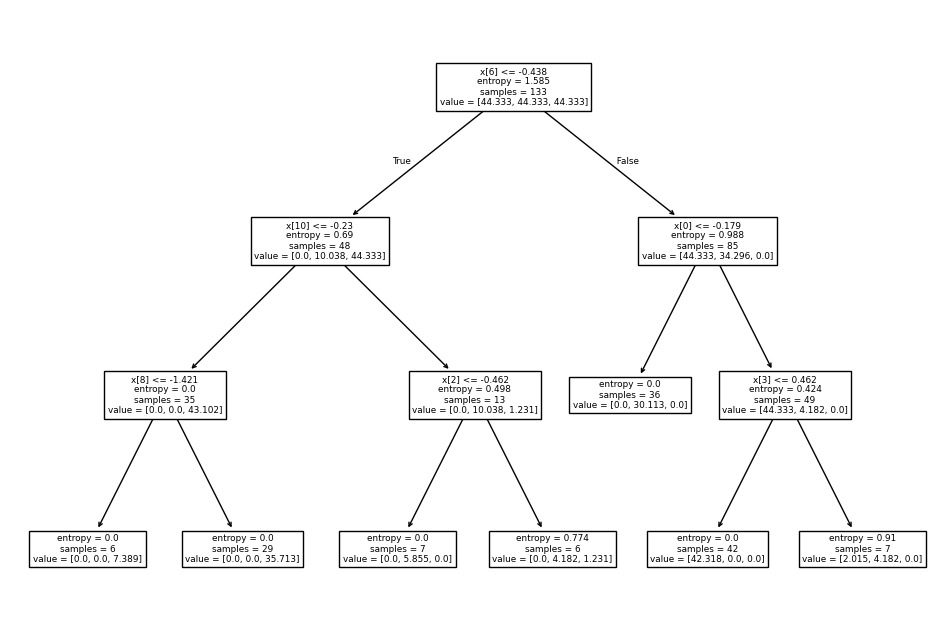

In [44]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(tree_model) 
None

As the visualization shows, the decision tree we obtained is quite compact, and there doesn't seem to be any room for further improvement (pruning, for instance, doesn't look promising).

Let's take a look at which classes the model is getting wrong

In [45]:
print(confusion_matrix(y_test, pred_tree))

[[15  0  0]
 [ 3 14  1]
 [ 0  1 11]]


The model identifies objects of class 0 with perfect accuracy. It performs worst at distinguishing objects of class 1. It might be possible to improve the situation by tuning class weights using `GridSearchCV`. Tree ensembles would also likely yield better results than a single tree, but we will not consider them, given that within the scope of this project we have already obtained a model with the maximum possible target metric value (logistic regression).

# Conclusions

The wine characteristics dataset `load_wine` from the `sklearn.datasets` library was under investigation in this project.

The performed exploratory data analysis (EDA) showed that the highest correlation occurs between the features `total_phenols` and `flavanoids`. However, given that the correlation coefficient is below 0.9, it was decided to retain all features for further processing. No outliers were detected in the data either. Standardization of the dataset was performed.

It was determined that the task under investigation (determining the wine class) is multiclass classification. The target variable consists of 3 classes (0, 1, 2). Class imbalance was noted. Therefore, the `f1_weighted` metric (weighted f1-score) was adopted as the target metric.

A logistic regression model was built. Cross-validation showed that in this problem, using the one-vs-rest and one-vs-one approaches for binary decomposition yields equivalent results, as neither provides an improvement in the target metric. Based on cross-validation grid search (using `GridSearchCV`), the optimal value of the regularization parameter was found to be `C = 0.06`. The `f1_weighted` score for the resulting model on the test set was 1.0.

A multiclass classification model based on the Support Vector Machine method was built. Given that in `scikit-learn`, the SVM for classification is implemented via the SVC class, which does not have a `multi_class` attribute or its equivalent, a composite model `OneVsRestClassifier(SVC())` was created. Since `GridSearchCV` cannot be applied directly to `SVC()` in this case, hyperparameter tuning via cross-validation for the created model was implemented explicitly. As a result, the optimal model was chosen with a linear kernel and regularization parameter `C = 0.31`. The target metric `f1_weighted` for the resulting model on the test set was 0.96. A more detailed analysis showed that the model misclassified one object from class 1 and one object from class 2. Objects of class 0 in the test set were classified without errors.

A multiclass classification model based on the KNN algorithm was built. Cross-validation tuning yielded the optimal number of neighbors `n_neighbors = 11`, as well as the method for determining neighbor weights. The target metric `f1_weighted` for the resulting model on the test set was 0.98. A more detailed analysis showed that the model misclassified only one object from class 1 (incorrectly assigned to class 2). Overall, the model performs well.

A classification model based on a decision tree was built, and optimal parameters were selected. The highest `f1_weighted` metric value achieved on the test set for this model was 0.89, which is significantly worse than the previously considered models. The model classified class 0 objects without errors but performed relatively poorly in identifying class 1 objects (true positive = 14, false negative = 4). The model could be improved by tuning optimal class weights or by switching to tree ensembles. However, training a tree takes more time than logistic regression.

Thus, **the logistic regression model with regularization parameter C = 0.06, automatic data balancing (class_weight='balanced'), and the one-vs-rest approach for handling the multiclass setting (multi_class='ovr'), which classified all test set objects without errors, was adopted as the final model**.

### Additional sources:
A useful article on dealing with class imbalance: https://www.analyticsvidhya.com/blog/2020/10/improve-class-imbalance-class-weights/ 